In [ ]:
!pip install scikit-image scikit-learn opencv-python matplotlib

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import joblib

In [ ]:
# -----------------------------
# UPLOAD DATASET FROM PC
# -----------------------------
from google.colab import files
uploaded = files.upload()

# -----------------------------
# UNZIP DATASET
# -----------------------------
import zipfile
import os

# Get uploaded file name
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Dataset extracted!")

# -----------------------------
# PARAMETERS
# -----------------------------
IMG_SIZE = (64, 64)
train_path = "/content/train/train"   # Make sure ZIP has 'train' folder inside

features = []
labels = []

# -----------------------------
# LOAD IMAGES
# -----------------------------
for category in os.listdir(train_path):
    category_path = os.path.join(train_path, category)

    if not os.path.isdir(category_path):
        continue

    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, IMG_SIZE)

        # HOG FEATURES
        hog_feature = hog(gray,
                          pixels_per_cell=(8,8),
                          cells_per_block=(2,2),
                          visualize=False)

        features.append(hog_feature)
        labels.append(category)

# -----------------------------
# CONVERT DATA
# -----------------------------
features = np.array(features)
labels = np.array(labels)

# -----------------------------
# ENCODE LABELS
# -----------------------------
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# -----------------------------
# TRAIN SVM
# -----------------------------
model = SVC(kernel='linear')
model.fit(features, labels_encoded)

# -----------------------------
# SAVE MODEL
# -----------------------------
joblib.dump(model, "road_sign_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Training Completed 👍")

KeyboardInterrupt: 

Saving 00032.png to 00032.png
Saving 00034.png to 00034.png
Saving 00107.png to 00107.png


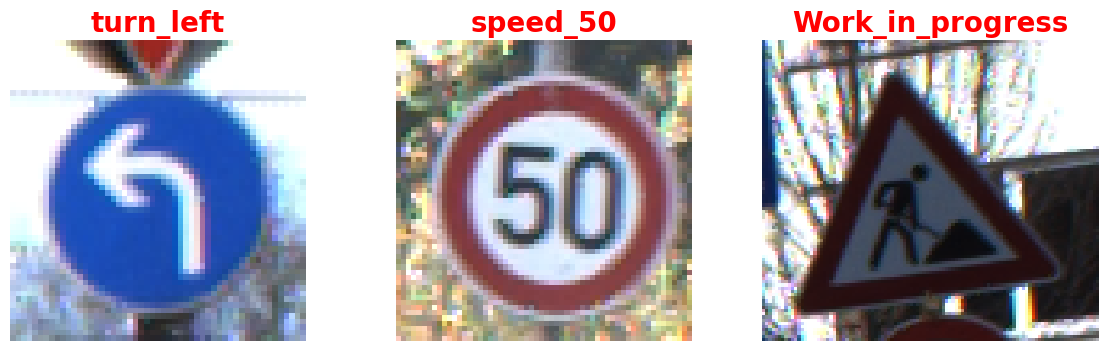

In [ ]:
import joblib
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from google.colab import files
import math

# -----------------------------
# LOAD TRAINED MODEL
# -----------------------------
model = joblib.load("road_sign_model.pkl")
le = joblib.load("label_encoder.pkl")

IMG_SIZE = (64, 64)

# -----------------------------
# UPLOAD TEST IMAGES FROM PC
# -----------------------------
uploaded = files.upload()

image_files = list(uploaded.keys())
num_images = len(image_files)

# AUTO GRID SIZE
cols = 3
rows = math.ceil(num_images / cols)

# CREATE FIGURE
plt.figure(figsize=(12, 4 * rows))

for i, img_name in enumerate(image_files):

    # READ IMAGE FROM UPLOADED FILE
    file_bytes = np.frombuffer(uploaded[img_name], np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if img is None:
        continue

    # PREPROCESS
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, IMG_SIZE)

    # HOG FEATURES
    hog_feature = hog(gray,
                      pixels_per_cell=(8,8),
                      cells_per_block=(2,2),
                      visualize=False)

    # PREDICT
    pred = model.predict([hog_feature])
    label = le.inverse_transform(pred)[0]

    # DISPLAY IN GRID
    plt.subplot(rows, cols, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"{label}", color='red', fontsize=20, fontweight='bold')
    plt.axis("off")

# SPACING
plt.tight_layout(pad=3.0)

# SHOW
plt.show()